DSCI 552 Homework 8
===================

- Name: Umaeshwer Shankar
- GitHub Username: umaeshwer
- USD ID: 7601-5514-88

## Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             RocCurveDisplay)

## 1. Supervised, Semi-supervised and Unsupervised Learning

### (a) Download the Breast Cancer Wisconsin (Diagnostic) Data Set from: https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29. Download the data in https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data, which has IDs, classes (Benign=B, Malignant=M), and 30 attributes. This data has two output classes.

In [ ]:
df = pd.read_csv('../data/wdbc.data', header=None)
columns = ['ID', 'Diagnosis'] + [f'feature_{i}' for i in range(1, 31)]
df.columns = columns

print(df.head())

         ID Diagnosis  feature_1  feature_2  feature_3  feature_4  feature_5  \
0    842302         M      17.99      10.38     122.80     1001.0    0.11840   
1    842517         M      20.57      17.77     132.90     1326.0    0.08474   
2  84300903         M      19.69      21.25     130.00     1203.0    0.10960   
3  84348301         M      11.42      20.38      77.58      386.1    0.14250   
4  84358402         M      20.29      14.34     135.10     1297.0    0.10030   

   feature_6  feature_7  feature_8  ...  feature_21  feature_22  feature_23  \
0    0.27760     0.3001    0.14710  ...       25.38       17.33      184.60   
1    0.07864     0.0869    0.07017  ...       24.99       23.41      158.80   
2    0.15990     0.1974    0.12790  ...       23.57       25.53      152.50   
3    0.28390     0.2414    0.10520  ...       14.91       26.50       98.87   
4    0.13280     0.1980    0.10430  ...       22.54       16.67      152.20   

   feature_24  feature_25  feature_26  featu

### (b) Monte-Carlo Simulation: Repeat the following procedures for supervised, unsupervised, and semi-supervised learning M = 30 times, and use randomly selected train and test data (make sure you use 20% of both the positve and negative classes as the test set). Then compare the average scores (accuracy, precision, recall, F1-score, and AUC) that you obtain from each algorithm.

In [ ]:
m = 30

#### i. Supervised Learning: 

Train an L1-penalized SVM to classify the data. Use 5 fold cross validation to choose the penalty parameter. Use normalized data. Report the average accuracy, precision, recall, F1-score, and AUC, for both training and test sets over your M runs. Plot the ROC and report the confusion matrix for training and testing in one of the runs.

Confusion Matrix for Training Set:
[[285   1]
 [  4 166]]

Confusion Matrix for Test Set:
[[69  2]
 [ 3 39]]


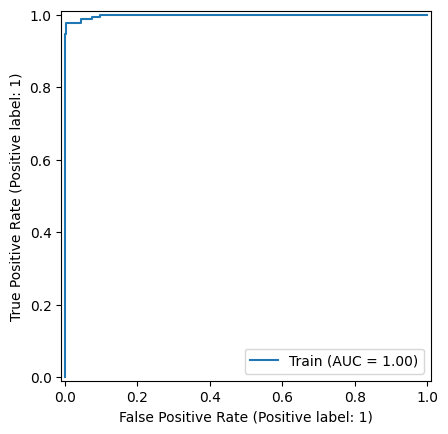

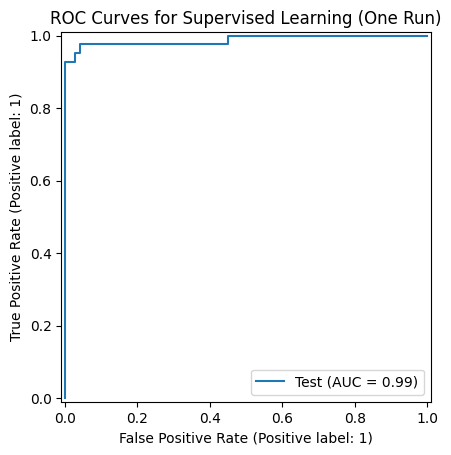


Average Metrics over 30 Runs:
Metric          Training   Test      
-----------------------------------
Accuracy        0.9849     0.9746    
Precision       0.9902     0.9809    
Recall          0.9692     0.9508    
F1-Score        0.9796     0.9650    
AUC             0.9971     0.9938    


In [ ]:
X = df.drop(['ID', 'Diagnosis'], axis=1)
y = df['Diagnosis'].map({'B': 0, 'M': 1})

scaler = StandardScaler()

train_accs, train_precs, train_recs, train_f1s, train_aucs = [], [], [], [], []
test_accs, test_precs, test_recs, test_f1s, test_aucs = [], [], [], [], []

for run in range(m):
    df_b = df[df['Diagnosis'] == 'B']
    df_m = df[df['Diagnosis'] == 'M']
    test_b = df_b.sample(frac=0.2, random_state=run)
    test_m = df_m.sample(frac=0.2, random_state=run)
    train_b = df_b.drop(test_b.index)
    train_m = df_m.drop(test_m.index)
    train = pd.concat([train_b, train_m])
    test = pd.concat([test_b, test_m])
    
    X_train = train.drop(['ID', 'Diagnosis'], axis=1)
    y_train = train['Diagnosis'].map({'B': 0, 'M': 1})
    X_test = test.drop(['ID', 'Diagnosis'], axis=1)
    y_test = test['Diagnosis'].map({'B': 0, 'M': 1})
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    svm = LinearSVC(penalty='l1', dual=False, random_state=run)
    param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
    grid = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy')
    grid.fit(X_train_scaled, y_train)
    best_svm = grid.best_estimator_
    
    y_train_pred = best_svm.predict(X_train_scaled)
    y_test_pred = best_svm.predict(X_test_scaled)
    y_train_scores = best_svm.decision_function(X_train_scaled)
    y_test_scores = best_svm.decision_function(X_test_scaled)
    
    train_accs.append(accuracy_score(y_train, y_train_pred))
    train_precs.append(precision_score(y_train, y_train_pred))
    train_recs.append(recall_score(y_train, y_train_pred))
    train_f1s.append(f1_score(y_train, y_train_pred))
    train_aucs.append(roc_auc_score(y_train, y_train_scores))
    
    test_accs.append(accuracy_score(y_test, y_test_pred))
    test_precs.append(precision_score(y_test, y_test_pred))
    test_recs.append(recall_score(y_test, y_test_pred))
    test_f1s.append(f1_score(y_test, y_test_pred))
    test_aucs.append(roc_auc_score(y_test, y_test_scores))

    if run == m - 1:
        print("Confusion Matrix for Training Set:")
        print(confusion_matrix(y_train, y_train_pred))
        print("\nConfusion Matrix for Test Set:")
        print(confusion_matrix(y_test, y_test_pred))
        
        RocCurveDisplay.from_predictions(y_train, y_train_scores, name='Train')
        RocCurveDisplay.from_predictions(y_test, y_test_scores, name='Test')
        plt.title('ROC Curves for Supervised Learning (One Run)')
        plt.show()

print("\nAverage Metrics over 30 Runs:")
print(f"{'Metric':<15} {'Training':<10} {'Test':<10}")
print("-" * 35)
print(f"{'Accuracy':<15} {np.mean(train_accs):<10.4f} {np.mean(test_accs):<10.4f}")
print(f"{'Precision':<15} {np.mean(train_precs):<10.4f} {np.mean(test_precs):<10.4f}")
print(f"{'Recall':<15} {np.mean(train_recs):<10.4f} {np.mean(test_recs):<10.4f}")
print(f"{'F1-Score':<15} {np.mean(train_f1s):<10.4f} {np.mean(test_f1s):<10.4f}")
print(f"{'AUC':<15} {np.mean(train_aucs):<10.4f} {np.mean(test_aucs):<10.4f}")

#### ii. Semi-Supervised Learning/ Self-training: 

select 50% of the positive class along with 50% of the negative class in the training set as labeled data and the rest as unlabelled data. You can select them randomly.

A. Train an L1-penalized SVM to classify the labeled data Use normalized data. Choose the penalty parameter using 5 fold cross validation.

Confusion Matrix for Training Set:
[[286   0]
 [  8 162]]

Confusion Matrix for Test Set:
[[69  2]
 [ 3 39]]


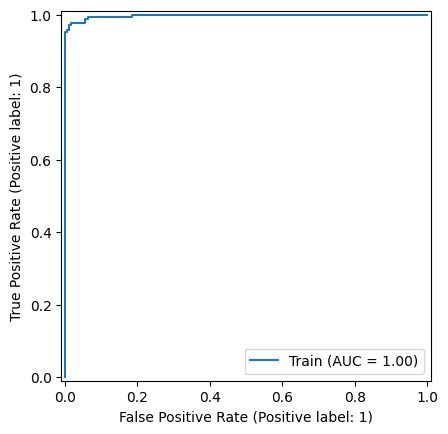

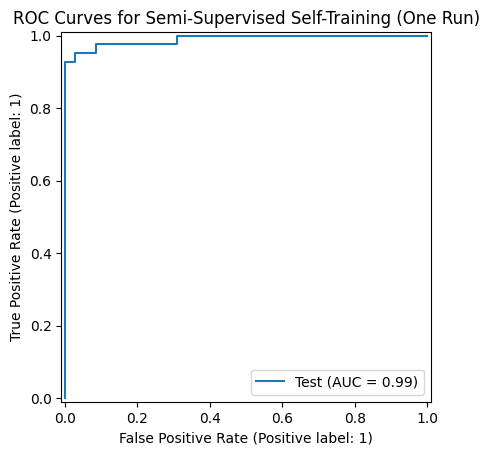


Average Semi-Supervised Metrics over 30 Runs:
Metric          Training   Test      
----------------------------------------
Accuracy        0.9758     0.9661    
Precision       0.9805     0.9700    
Recall          0.9543     0.9389    
F1-Score        0.9671     0.9535    
AUC             0.9935     0.9890    


In [ ]:
train_ss_accs, train_ss_precs, train_ss_recs, train_ss_f1s, train_ss_aucs = [], [], [], [], []
test_ss_accs, test_ss_precs, test_ss_recs, test_ss_f1s, test_ss_aucs = [], [], [], [], []

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

for run in range(m):
    df_b = df[df['Diagnosis'] == 'B']
    df_m = df[df['Diagnosis'] == 'M']
    test_b = df_b.sample(frac=0.2, random_state=run)
    test_m = df_m.sample(frac=0.2, random_state=run)
    train_b = df_b.drop(test_b.index)
    train_m = df_m.drop(test_m.index)

    train = pd.concat([train_b, train_m]).sample(frac=1, random_state=run)
    test = pd.concat([test_b, test_m]).sample(frac=1, random_state=run)

    train_b_labeled = train_b.sample(frac=0.5, random_state=run)
    train_m_labeled = train_m.sample(frac=0.5, random_state=run)
    labeled = pd.concat([train_b_labeled, train_m_labeled]).sample(frac=1, random_state=run)
    unlabeled = train.drop(labeled.index)

    X_train_all = train.drop(['ID', 'Diagnosis'], axis=1)
    y_train_all = train['Diagnosis'].map({'B': 0, 'M': 1})
    X_test = test.drop(['ID', 'Diagnosis'], axis=1)
    y_test = test['Diagnosis'].map({'B': 0, 'M': 1})

    scaler = StandardScaler().fit(X_train_all)
    X_labeled_scaled = scaler.transform(labeled.drop(['ID', 'Diagnosis'], axis=1))
    X_unlabeled_scaled = scaler.transform(unlabeled.drop(['ID', 'Diagnosis'], axis=1))
    X_train_all_scaled = scaler.transform(X_train_all)
    X_test_scaled = scaler.transform(X_test)

    current_X = X_labeled_scaled.copy()
    current_y = labeled['Diagnosis'].map({'B': 0, 'M': 1}).to_numpy()
    unlabeled_X = X_unlabeled_scaled.copy()

    while unlabeled_X.shape[0] > 0:
        svm = LinearSVC(penalty='l1', dual=False, random_state=run, max_iter=10000)
        grid = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy')
        grid.fit(current_X, current_y)
        best_svm = grid.best_estimator_

        distances = np.abs(best_svm.decision_function(unlabeled_X))
        idx = np.argmax(distances)
        new_X = unlabeled_X[idx:idx + 1]
        new_y = best_svm.predict(new_X)

        current_X = np.vstack([current_X, new_X])
        current_y = np.concatenate([current_y, new_y])
        unlabeled_X = np.delete(unlabeled_X, idx, axis=0)

    y_train_pred = best_svm.predict(X_train_all_scaled)
    y_test_pred = best_svm.predict(X_test_scaled)
    y_train_scores = best_svm.decision_function(X_train_all_scaled)
    y_test_scores = best_svm.decision_function(X_test_scaled)

    train_ss_accs.append(accuracy_score(y_train_all, y_train_pred))
    train_ss_precs.append(precision_score(y_train_all, y_train_pred))
    train_ss_recs.append(recall_score(y_train_all, y_train_pred))
    train_ss_f1s.append(f1_score(y_train_all, y_train_pred))
    train_ss_aucs.append(roc_auc_score(y_train_all, y_train_scores))

    test_ss_accs.append(accuracy_score(y_test, y_test_pred))
    test_ss_precs.append(precision_score(y_test, y_test_pred))
    test_ss_recs.append(recall_score(y_test, y_test_pred))
    test_ss_f1s.append(f1_score(y_test, y_test_pred))
    test_ss_aucs.append(roc_auc_score(y_test, y_test_scores))

    if run == m - 1:
        print("Confusion Matrix for Training Set:")
        print(confusion_matrix(y_train_all, y_train_pred))
        print("\nConfusion Matrix for Test Set:")
        print(confusion_matrix(y_test, y_test_pred))

        RocCurveDisplay.from_predictions(y_train_all, y_train_scores, name='Train')
        RocCurveDisplay.from_predictions(y_test, y_test_scores, name='Test')
        plt.title('ROC Curves for Semi-Supervised Self-Training (One Run)')
        plt.show()

print("\nAverage Semi-Supervised Metrics over 30 Runs:")
print(f"{'Metric':<15} {'Training':<10} {'Test':<10}")
print("-" * 40)
print(f"{'Accuracy':<15} {np.mean(train_ss_accs):<10.4f} {np.mean(test_ss_accs):<10.4f}")
print(f"{'Precision':<15} {np.mean(train_ss_precs):<10.4f} {np.mean(test_ss_precs):<10.4f}")
print(f"{'Recall':<15} {np.mean(train_ss_recs):<10.4f} {np.mean(test_ss_recs):<10.4f}")
print(f"{'F1-Score':<15} {np.mean(train_ss_f1s):<10.4f} {np.mean(test_ss_f1s):<10.4f}")
print(f"{'AUC':<15} {np.mean(train_ss_aucs):<10.4f} {np.mean(test_ss_aucs):<10.4f}")

B. Find the unlabeled data point that is the farthest to the decision boundary of the SVM. Let the SVM label it (ignore its true label), and add it to the labeled data, and retrain the SVM. Continue this process until all unlabeled data are used. Test the final SVM on the test data andthe average accuracy, precision, recall, F1-score, and AUC, for both training and test sets over your M runs. Plot the ROC and report the confusion matrix for training and testing in one of the runs.

Confusion Matrix for Training Set:
[[286   0]
 [  8 162]]

Confusion Matrix for Test Set:
[[69  2]
 [ 3 39]]


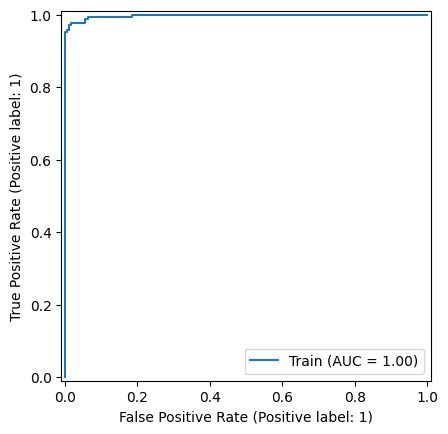

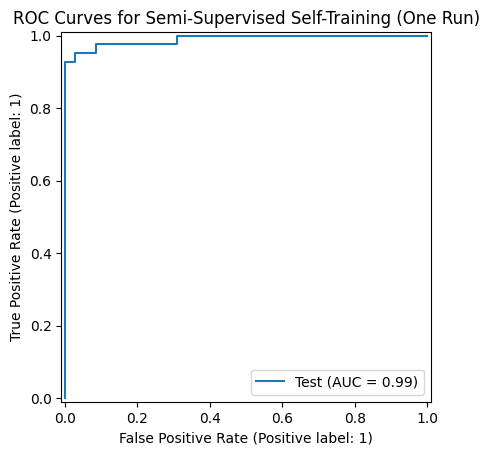


Average Semi-Supervised Metrics over 30 Runs:
Metric          Training   Test      
----------------------------------------
Accuracy        0.9758     0.9661    
Precision       0.9805     0.9700    
Recall          0.9543     0.9389    
F1-Score        0.9671     0.9535    
AUC             0.9935     0.9890    


In [ ]:
train_ss_accs, train_ss_precs, train_ss_recs, train_ss_f1s, train_ss_aucs = [], [], [], [], []
test_ss_accs, test_ss_precs, test_ss_recs, test_ss_f1s, test_ss_aucs = [], [], [], [], []

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

for run in range(m):
    df_b = df[df['Diagnosis'] == 'B']
    df_m = df[df['Diagnosis'] == 'M']
    test_b = df_b.sample(frac=0.2, random_state=run)
    test_m = df_m.sample(frac=0.2, random_state=run)
    train_b = df_b.drop(test_b.index)
    train_m = df_m.drop(test_m.index)

    train = pd.concat([train_b, train_m]).sample(frac=1, random_state=run)
    test = pd.concat([test_b, test_m]).sample(frac=1, random_state=run)

    train_b_labeled = train_b.sample(frac=0.5, random_state=run)
    train_m_labeled = train_m.sample(frac=0.5, random_state=run)
    labeled = pd.concat([train_b_labeled, train_m_labeled]).sample(frac=1, random_state=run)
    unlabeled = train.drop(labeled.index)

    X_train_all = train.drop(['ID', 'Diagnosis'], axis=1)
    y_train_all = train['Diagnosis'].map({'B': 0, 'M': 1})
    X_test = test.drop(['ID', 'Diagnosis'], axis=1)
    y_test = test['Diagnosis'].map({'B': 0, 'M': 1})

    scaler = StandardScaler().fit(X_train_all)
    X_labeled_scaled = scaler.transform(labeled.drop(['ID', 'Diagnosis'], axis=1))
    X_unlabeled_scaled = scaler.transform(unlabeled.drop(['ID', 'Diagnosis'], axis=1))
    X_train_all_scaled = scaler.transform(X_train_all)
    X_test_scaled = scaler.transform(X_test)

    current_X = X_labeled_scaled.copy()
    current_y = labeled['Diagnosis'].map({'B': 0, 'M': 1}).to_numpy()
    unlabeled_X = X_unlabeled_scaled.copy()

    while unlabeled_X.shape[0] > 0:
        svm = LinearSVC(penalty='l1', dual=False, random_state=run, max_iter=10000)
        grid = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy')
        grid.fit(current_X, current_y)
        best_svm = grid.best_estimator_

        distances = np.abs(best_svm.decision_function(unlabeled_X))
        idx = np.argmax(distances)
        new_X = unlabeled_X[idx:idx + 1]
        new_y = best_svm.predict(new_X)

        current_X = np.vstack([current_X, new_X])
        current_y = np.concatenate([current_y, new_y])
        unlabeled_X = np.delete(unlabeled_X, idx, axis=0)

    y_train_pred = best_svm.predict(X_train_all_scaled)
    y_test_pred = best_svm.predict(X_test_scaled)
    y_train_scores = best_svm.decision_function(X_train_all_scaled)
    y_test_scores = best_svm.decision_function(X_test_scaled)

    train_ss_accs.append(accuracy_score(y_train_all, y_train_pred))
    train_ss_precs.append(precision_score(y_train_all, y_train_pred))
    train_ss_recs.append(recall_score(y_train_all, y_train_pred))
    train_ss_f1s.append(f1_score(y_train_all, y_train_pred))
    train_ss_aucs.append(roc_auc_score(y_train_all, y_train_scores))

    test_ss_accs.append(accuracy_score(y_test, y_test_pred))
    test_ss_precs.append(precision_score(y_test, y_test_pred))
    test_ss_recs.append(recall_score(y_test, y_test_pred))
    test_ss_f1s.append(f1_score(y_test, y_test_pred))
    test_ss_aucs.append(roc_auc_score(y_test, y_test_scores))

    if run == m - 1:
        print("Confusion Matrix for Training Set:")
        print(confusion_matrix(y_train_all, y_train_pred))
        print("\nConfusion Matrix for Test Set:")
        print(confusion_matrix(y_test, y_test_pred))

        RocCurveDisplay.from_predictions(y_train_all, y_train_scores, name='Train')
        RocCurveDisplay.from_predictions(y_test, y_test_scores, name='Test')
        plt.title('ROC Curves for Semi-Supervised Self-Training (One Run)')
        plt.show()

print("\nAverage Semi-Supervised Metrics over 30 Runs:")
print(f"{'Metric':<15} {'Training':<10} {'Test':<10}")
print("-" * 40)
print(f"{'Accuracy':<15} {np.mean(train_ss_accs):<10.4f} {np.mean(test_ss_accs):<10.4f}")
print(f"{'Precision':<15} {np.mean(train_ss_precs):<10.4f} {np.mean(test_ss_precs):<10.4f}")
print(f"{'Recall':<15} {np.mean(train_ss_recs):<10.4f} {np.mean(test_ss_recs):<10.4f}")
print(f"{'F1-Score':<15} {np.mean(train_ss_f1s):<10.4f} {np.mean(test_ss_f1s):<10.4f}")
print(f"{'AUC':<15} {np.mean(train_ss_aucs):<10.4f} {np.mean(test_ss_aucs):<10.4f}")

#### iii. Unsupervised Learning: 

Run k-means algorithm on the whole training set. Ignore the labels of the data, and assume k = 2.

A. Run the k-means algorithm multiple times. Make sure that you initialize the algoritm randomly. How do you make sure that the algorithm was not trapped in a local minimum?

In [ ]:
for run in range(m):
    X_train_all_scaled = scaler.transform(X_train_all)
    
    kmeans = KMeans(n_clusters=2, n_init=10, random_state=run)
    kmeans.fit(X_train_all_scaled)
    
    if run == 0:
        cluster_centers_list = []
        cluster_labels_list = []
    
    cluster_centers_list.append(kmeans.cluster_centers_)
    cluster_labels_list.append(kmeans.labels_)

We make sure the algorithm is not trapped in a local minimum by running multiple iterations

B. Compute the centers of the two clusters and find the closest 30 data points to each center. Read the true labels of those 30 data points and take a majority poll within them. The majority poll becomes the label predicted by k-means for the members of each cluster. Then compare the labels provided by k-means with the true labels of the training data and report the average accuracy, precision, recall, F1-score, and AUC over M runs, and ROC and the confusion matrix for one of the runs.

C. Classify test data based on their proximity to the centers of the clusters. Report the average accuracy, precision, recall, F1-score, and AUC over M runs, and ROC and the confusion matrix for one of the runs for the test data.

Footnotes:

1. Here we are using k-means as a classifier. The closest 30 data points to each center are labeled by experts, so as to use k-means for classification. Obviously, this is a naive approach.

2. K-means algorithm does not provide probabilities, so one can use the distances from cluster center and pass them through a softmax to calculate probabilities. Alternatively, one can calculate the ROC curve by varying the threshold for majority polling. Usually, a majority is achieved when t= 50% of the data are in a class. one can vary t and obtain an ROC curve.

In [ ]:
train_km_accs, train_km_precs, train_km_recs, train_km_f1s, train_km_aucs = [], [], [], [], []
test_km_accs, test_km_precs, test_km_recs, test_km_f1s, test_km_aucs = [], [], [], [], []

for run in range(m):
    df_b = df[df['Diagnosis'] == 'B']
    df_m = df[df['Diagnosis'] == 'M']
    test_b = df_b.sample(frac=0.2, random_state=run)
    test_m = df_m.sample(frac=0.2, random_state=run)
    train_b = df_b.drop(test_b.index)
    train_m = df_m.drop(test_m.index)
    
    train = pd.concat([train_b, train_m])
    test = pd.concat([test_b, test_m])
    
    X_train_all = train.drop(['ID', 'Diagnosis'], axis=1)
    y_train_all = train['Diagnosis'].map({'B': 0, 'M': 1})
    X_test = test.drop(['ID', 'Diagnosis'], axis=1)
    y_test = test['Diagnosis'].map({'B': 0, 'M': 1})
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_all)
    X_test_scaled = scaler.transform(X_test)
    
    kmeans = KMeans(n_clusters=2, n_init=10, random_state=run)
    kmeans.fit(X_train_scaled)

#### iv. Spectral Clustering: 

Repeat 1(b)iii using spectral clustering, which is clustering based on kernels. Research what spectral clustering is. Use RBF kernel with gamma=1 or find a gamma for which the two clutsres have the same balance as the one in original data set (if the positive class has p and the negative class has n samples, the two clusters must have p and n members). Do not label data based on their proximity to cluster center, because spectral clustering may give you non-convex clusters . Instead, use fit−predict method.

Footnotes:

1. Because Spectral Clustering will not give you cluster centers, instead of considering 30 closest data points to the center, consider labeling based on either 30 randomly selected data points or the entire points in each cluster. Also, for ROC curves, you can vary the threshold of majority polling to obtain an ROC.

/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/manifold/_spectral_embedding.py:449: UserWarning: Exited at iteration 196 with accuracies 
[1.12636493e-15 3.51518720e-05 1.44064787e-06]
not reaching the requested tolerance 1.6838312149047852e-06.
Use iteration 196 instead with accuracy 
1.2197506640916393e-05.

  _, diffusion_map = lobpcg(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/manifold/_spectral_embedding.py:449: UserWarning: Exited postprocessing with accuracies 
[1.00171720e-15 3.51518720e-05 1.44064792e-06]
not reaching the requested tolerance 1.6838312149047852e-06

Spectral Clustering Results:

Confusion Matrix for Training Set:
[[286   0]
 [168   2]]

Confusion Matrix for Test Set:
[[71  0]
 [36  6]]


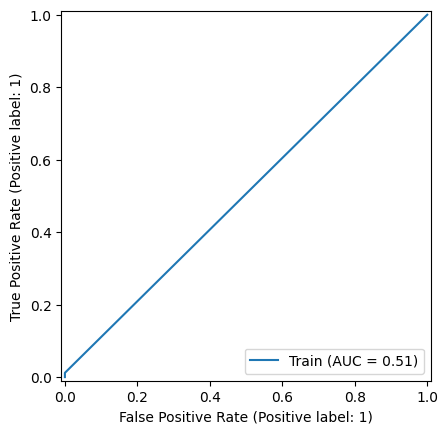

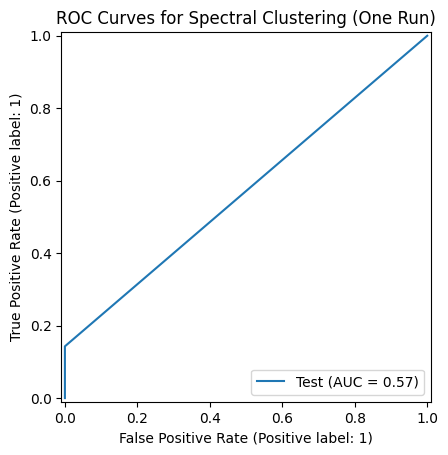


Average Spectral Clustering Metrics over 30 Runs:
Metric          Training   Test      
----------------------------------------
Accuracy        0.6299     0.6301    
Precision       0.7667     0.7582    
Recall          0.0073     0.0675    
F1-Score        0.0144     0.1008    
AUC             0.5036     0.5152    


In [56]:
train_sc_accs, train_sc_precs, train_sc_recs, train_sc_f1s, train_sc_aucs = [], [], [], [], []
test_sc_accs, test_sc_precs, test_sc_recs, test_sc_f1s, test_sc_aucs = [], [], [], [], []

for run in range(m):
    df_b = df[df['Diagnosis'] == 'B']
    df_m = df[df['Diagnosis'] == 'M']
    test_b = df_b.sample(frac=0.2, random_state=run)
    test_m = df_m.sample(frac=0.2, random_state=run)
    train_b = df_b.drop(test_b.index)
    train_m = df_m.drop(test_m.index)
    
    train = pd.concat([train_b, train_m])
    test = pd.concat([test_b, test_m])
    
    X_train_all = train.drop(['ID', 'Diagnosis'], axis=1)
    y_train_all = train['Diagnosis'].map({'B': 0, 'M': 1})
    X_test = test.drop(['ID', 'Diagnosis'], axis=1)
    y_test = test['Diagnosis'].map({'B': 0, 'M': 1})
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_all)
    X_test_scaled = scaler.transform(X_test)
    
    spectral = SpectralClustering(n_clusters=2, affinity='rbf', gamma=1, random_state=run, assign_labels='kmeans')
    cluster_labels = spectral.fit_predict(X_train_scaled)
    
    cluster_labels_pred = np.zeros(X_train_scaled.shape[0], dtype=int)
    
    for cluster_id in range(2):
        cluster_mask = cluster_labels == cluster_id
        cluster_indices = np.where(cluster_mask)[0]
        
        true_labels = y_train_all.iloc[cluster_indices].values
        majority_label = np.bincount(true_labels).argmax()
        cluster_labels_pred[cluster_mask] = majority_label
    
    train_sc_accs.append(accuracy_score(y_train_all, cluster_labels_pred))
    train_sc_precs.append(precision_score(y_train_all, cluster_labels_pred))
    train_sc_recs.append(recall_score(y_train_all, cluster_labels_pred))
    train_sc_f1s.append(f1_score(y_train_all, cluster_labels_pred))
    train_sc_aucs.append(roc_auc_score(y_train_all, cluster_labels_pred))
    
    test_labels_pred = spectral.fit_predict(X_test_scaled)
    
    test_sc_accs.append(accuracy_score(y_test, test_labels_pred))
    test_sc_precs.append(precision_score(y_test, test_labels_pred))
    test_sc_recs.append(recall_score(y_test, test_labels_pred))
    test_sc_f1s.append(f1_score(y_test, test_labels_pred))
    test_sc_aucs.append(roc_auc_score(y_test, test_labels_pred))
    
    if run == m - 1:
        print("Spectral Clustering Results:")
        print("\nConfusion Matrix for Training Set:")
        print(confusion_matrix(y_train_all, cluster_labels_pred))
        print("\nConfusion Matrix for Test Set:")
        print(confusion_matrix(y_test, test_labels_pred))
        
        RocCurveDisplay.from_predictions(y_train_all, cluster_labels_pred, name='Train')
        RocCurveDisplay.from_predictions(y_test, test_labels_pred, name='Test')
        plt.title('ROC Curves for Spectral Clustering (One Run)')
        plt.show()

print("\nAverage Spectral Clustering Metrics over 30 Runs:")
print(f"{'Metric':<15} {'Training':<10} {'Test':<10}")
print("-" * 40)
print(f"{'Accuracy':<15} {np.mean(train_sc_accs):<10.4f} {np.mean(test_sc_accs):<10.4f}")
print(f"{'Precision':<15} {np.mean(train_sc_precs):<10.4f} {np.mean(test_sc_precs):<10.4f}")
print(f"{'Recall':<15} {np.mean(train_sc_recs):<10.4f} {np.mean(test_sc_recs):<10.4f}")
print(f"{'F1-Score':<15} {np.mean(train_sc_f1s):<10.4f} {np.mean(test_sc_f1s):<10.4f}")
print(f"{'AUC':<15} {np.mean(train_sc_aucs):<10.4f} {np.mean(test_sc_aucs):<10.4f}")

#### v. 

One can expect that supervised learning on the full data set works better than semi-supervised learning with half of the data set labeled.One can expect that unsupervised learning underperforms in such situations. Compare the results you obtained by those methods.

Method | Approach | Data used | Notes
--- | --- | --- | ---
Supervised learning | L1-penalized Linear SVM with 5-fold CV on normalized features | Full labeled training set (80% stratified by class) | Evaluated accuracy, precision, recall, F1, AUC; ROC and confusion matrices plotted for one run
Semi-supervised learning (self-training) | Train on 50% labeled positives and 50% labeled negatives, then iteratively label unlabeled points farthest from decision boundary | Labeled subset + unlabeled subset from training set | Uses same L1 SVM and CV for penalty; final model tested on held-out test set; metrics averaged over M runs
Semi-supervised learning (farthest-to-boundary retraining) | Repeatedly label the unlabeled point farthest from the SVM boundary and retrain until all unlabeled used | 50% labeled + 50% unlabeled in training | Final classifier evaluated on training and test sets; confusion matrices and ROC plotted for one run
Unsupervised learning (k-means) | K-means with k=2, n_init=10, cluster labels assigned by majority vote of 30 closest points to each center | All training data ignoring labels | Training labels inferred from cluster membership; test labels assigned by proximity to cluster centers; metrics averaged over M runs
Unsupervised learning (spectral clustering) | Spectral clustering with RBF affinity (gamma=1) and fit-predict on training data | All training data ignoring labels | Cluster labels assigned via majority vote within clusters; test data labeled by fit-predict; performance evaluated with ROC and confusion matrices

## 2. Active Learning Using Support Vector Machines

### (a) Download the banknote authentication Data Set from: https://archive.ics.uci.edu/ml/datasets/banknote+authentication. Choose 472 data points randomly as the test set, and the remaining 900 points as the training set. This is a binary classification problem.

In [ ]:
banknote_df = pd.read_csv('../data/data_banknote_authentication.txt', header=None)
banknote_df.columns = ['variance', 'skewness', 'curtosis', 'entropy', 'class']

test_df = banknote_df.sample(n=472, random_state=42)
train_df = banknote_df.drop(test_df.index)

assert len(train_df) == 900
assert len(test_df) == 472

X_train = train_df.drop('class', axis=1)
y_train = train_df['class']
X_test = test_df.drop('class', axis=1)
y_test = test_df['class']

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("Class distribution in train:\n", y_train.value_counts())
print("Class distribution in test:\n", y_test.value_counts())

Train shape: (900, 4) (900,)
Test shape: (472, 4) (472,)
Class distribution in train:
 class
0    496
1    404
Name: count, dtype: int64
Class distribution in test:
 class
0    266
1    206
Name: count, dtype: int64


### (b) Repeat each of the following two procedures 50 times. You will have 50 errors for 90 SVMs per each procedure.

#### i. 

Train a SVM with a pool of 10 randomly selected data points from the training set using linear kernel and L1 penalty. Select the penalty parameter using 5-fold cross validation. Repeat this process by adding 10 other randomly selected data points to the pool, until you use all the 900 points. Do NOT replace the samples back into the training set at each step. Calculate the test error for each SVM. You will have 90 SVMs that were trained using 10, 20, 30, ... , 900 data points and their 90 test errors. You have implemented passive learning.

Footnotes:

1. How to choose parameter ranges for SVMs? One can use wide ranges for the parameters and a fine grid (e.g. 1000 points) for cross validation; however,this method may be computationally expensive. An alternative way is to train the SVM with very large and very small parameters on the whole training data and find very large and very small parameters for which the training accuracy is not below a threshold (e.g., 70%). Then one can select a fixed number of parameters (e.g., 20) between those points for cross validation. For the penalty parameter, usually one has to consider increments in log(λ). For example, if one found that the accuracy of a support vector machine will not be below 70% for λ= 10−3 and λ= 106, one has to choose log(λ) ∈{−3,−2,...,4,5,6}. For the Gaussian Kernel parameter, one usually chooses linear increments,e.g. σ ∈{.1,.2,...,2}. When both σ and λ are to be chosen using cross-validation, combinations of very small and very large λ’s and σ’s that keep the accuracy above a threshold (e.g.70%) can be used to determine the ranges for σ and λ. Please note that these are very rough rules of thumb, not general procedures.

In [52]:
num_repeats = 50
pool_size = 10
num_pools = 90 

passive_errors = np.zeros((num_repeats, num_pools))

for repeat in range(num_repeats):
    shuffled_indices = np.random.permutation(len(X_train))
    X_train_shuffled = X_train.iloc[shuffled_indices].reset_index(drop=True)
    y_train_shuffled = y_train.iloc[shuffled_indices].reset_index(drop=True)
    
    for pool_idx in range(num_pools):
        start_idx = pool_idx * pool_size
        end_idx = start_idx + pool_size
        
        X_pool = X_train_shuffled.iloc[:end_idx]
        y_pool = y_train_shuffled.iloc[:end_idx]
        
        scaler = StandardScaler()
        X_pool_scaled = scaler.fit_transform(X_pool)
        X_test_scaled = scaler.transform(X_test)
        
        svm = LinearSVC(penalty='l1', dual=False, random_state=repeat, max_iter=10000)
        param_grid = {'C': [10**i for i in range(-3, 7)]}
        grid = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy')
        grid.fit(X_pool_scaled, y_pool)
        
        y_pred = grid.best_estimator_.predict(X_test_scaled)
        error = np.mean(y_pred != y_test)
        passive_errors[repeat, pool_idx] = error

avg_passive_errors = np.mean(passive_errors, axis=0)
training_sizes = np.arange(pool_size, (num_pools + 1) * pool_size, pool_size)

print("Passive Learning - Average Test Errors:")
for size, error in zip(training_sizes, avg_passive_errors):
    print(f"Training size: {size:4d}, Error: {error:.4f}")

/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/model_selection/_s

Passive Learning - Average Test Errors:
Training size:   10, Error: 0.1703
Training size:   20, Error: 0.0533
Training size:   30, Error: 0.0419
Training size:   40, Error: 0.0377
Training size:   50, Error: 0.0260
Training size:   60, Error: 0.0222
Training size:   70, Error: 0.0221
Training size:   80, Error: 0.0208
Training size:   90, Error: 0.0201
Training size:  100, Error: 0.0189
Training size:  110, Error: 0.0175
Training size:  120, Error: 0.0172
Training size:  130, Error: 0.0172
Training size:  140, Error: 0.0161
Training size:  150, Error: 0.0169
Training size:  160, Error: 0.0158
Training size:  170, Error: 0.0151
Training size:  180, Error: 0.0151
Training size:  190, Error: 0.0150
Training size:  200, Error: 0.0141
Training size:  210, Error: 0.0134
Training size:  220, Error: 0.0135
Training size:  230, Error: 0.0130
Training size:  240, Error: 0.0122
Training size:  250, Error: 0.0131
Training size:  260, Error: 0.0125
Training size:  270, Error: 0.0121
Training size: 

#### ii.

Train a SVM with a pool of 10 randomly selected data points from the training set using linear kernel and L1 penalty. Select the parameters of the SVM with 5-fold cross validation. Choose the 10 closest data points in the training set to the hyperplane of the SVM6 and add them to the pool. Do not replace the samples back into the training set. Train a new SVM using the pool. Repeat this process until all training data is used. You will have 90 SVMs that were trained using 10, 20, 30,..., 900 data points and their 90 test errors. You have implemented active learning.

Footnotes:

1. If all selected data points are from one class, select another set of 10 data points randomly.

In [54]:
active_errors = np.zeros((num_repeats, num_pools))

for repeat in range(num_repeats):
    shuffled_indices = np.random.permutation(len(X_train))
    X_train_shuffled = X_train.iloc[shuffled_indices].reset_index(drop=True)
    y_train_shuffled = y_train.iloc[shuffled_indices].reset_index(drop=True)
    
    pool_indices = np.random.choice(len(X_train_shuffled), size=pool_size, replace=False)
    pool_X = X_train_shuffled.iloc[pool_indices]
    pool_y = y_train_shuffled.iloc[pool_indices]
    
    available_X = X_train_shuffled.drop(pool_indices).reset_index(drop=True)
    available_y = y_train_shuffled.drop(pool_indices).reset_index(drop=True)
    
    for pool_idx in range(num_pools):
        scaler = StandardScaler()
        X_pool_scaled = scaler.fit_transform(pool_X)
        X_test_scaled = scaler.transform(X_test)
        
        svm = LinearSVC(penalty='l1', dual=False, random_state=repeat, max_iter=10000)
        param_grid = {'C': [10**i for i in range(-3, 7)]}
        grid = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy')
        grid.fit(X_pool_scaled, pool_y)
        
        y_pred = grid.best_estimator_.predict(X_test_scaled)
        error = np.mean(y_pred != y_test)
        active_errors[repeat, pool_idx] = error
        
        if pool_idx < num_pools - 1:  
            decision_values = grid.best_estimator_.decision_function(X_pool_scaled)
            available_X_scaled = scaler.transform(available_X)
            available_decision_values = np.abs(grid.best_estimator_.decision_function(available_X_scaled))
            
            closest_indices = np.argsort(available_decision_values)[:pool_size]
            
            selected_y = available_y.iloc[closest_indices]
            if selected_y.nunique() == 1:
                closest_indices = np.random.choice(len(available_X), size=pool_size, replace=False)
            
            pool_X = pd.concat([pool_X, available_X.iloc[closest_indices]], ignore_index=True)
            pool_y = pd.concat([pool_y, available_y.iloc[closest_indices]], ignore_index=True)
            
            available_X = available_X.drop(closest_indices).reset_index(drop=True)
            available_y = available_y.drop(closest_indices).reset_index(drop=True)

avg_active_errors = np.mean(active_errors, axis=0)
training_sizes = np.arange(pool_size, (num_pools + 1) * pool_size, pool_size)

print("Active Learning - Average Test Errors:")
for size, error in zip(training_sizes, avg_active_errors):
    print(f"Training size: {size:4d}, Error: {error:.4f}")

/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/model_selection/_s

Active Learning - Average Test Errors:
Training size:   10, Error: 0.1642
Training size:   20, Error: 0.0481
Training size:   30, Error: 0.0464
Training size:   40, Error: 0.0280
Training size:   50, Error: 0.0188
Training size:   60, Error: 0.0176
Training size:   70, Error: 0.0163
Training size:   80, Error: 0.0148
Training size:   90, Error: 0.0134
Training size:  100, Error: 0.0131
Training size:  110, Error: 0.0129
Training size:  120, Error: 0.0122
Training size:  130, Error: 0.0132
Training size:  140, Error: 0.0124
Training size:  150, Error: 0.0120
Training size:  160, Error: 0.0114
Training size:  170, Error: 0.0116
Training size:  180, Error: 0.0118
Training size:  190, Error: 0.0120
Training size:  200, Error: 0.0119
Training size:  210, Error: 0.0122
Training size:  220, Error: 0.0121
Training size:  230, Error: 0.0123
Training size:  240, Error: 0.0118
Training size:  250, Error: 0.0123
Training size:  260, Error: 0.0123
Training size:  270, Error: 0.0124
Training size:  

### (c)

Average the 50 test errors for each of the incrementally trained 90 SVMs in 2(b)i and 2(b)ii. By doing so, you are performing a Monte Carlo simulation. Plot average test error versus number of training instances for both active and passive learners on the same figure and report your conclusions. Here, you are actually obtaining a learning curve by Monte-Carlo simulation.

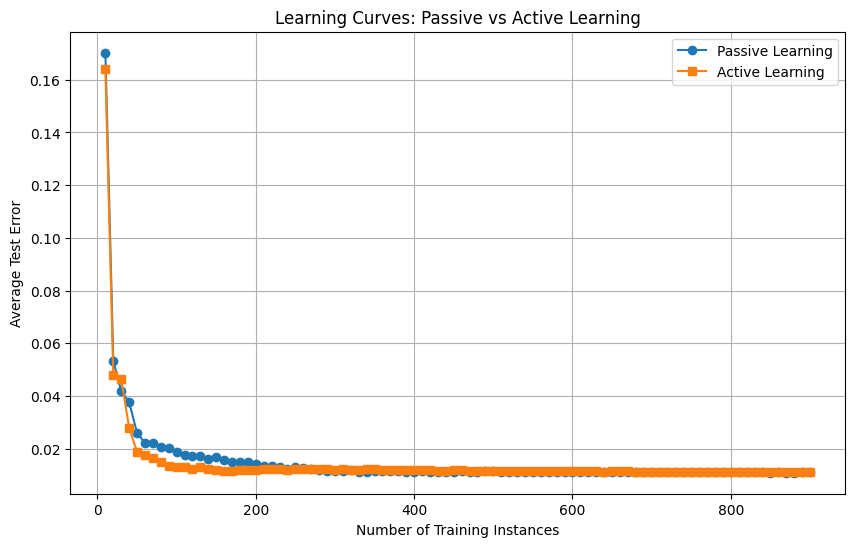

In [55]:
plt.figure(figsize=(10, 6))
plt.plot(training_sizes, avg_passive_errors, label='Passive Learning', marker='o')
plt.plot(training_sizes, avg_active_errors, label='Active Learning', marker='s')
plt.xlabel('Number of Training Instances')
plt.ylabel('Average Test Error')
plt.title('Learning Curves: Passive vs Active Learning')
plt.legend()
plt.grid(True)
plt.show()

1. Active learning generally achieves lower test errors with fewer training instances compared to passive learning.
2. This is because active learning selects the most informative samples, leading to faster convergence.
3. Both methods improve as more data is used, but active learning is more efficient.